# iCMAB: Comprehensive Stochastic Environment Performance Analysis

## Research Implementation
**Graduate Assistant Research - AI/Quantum Computing**  
**Rochester Institute of Technology**

---

### Research Objectives

This notebook provides a comprehensive evaluation of the **iCMAB (Informed Contextual Multi-Armed Bandit)** framework with focus on:

- **Stochastic Environments**: Natural fluctuations in network conditions and traffic patterns
- **Predictive Intelligence**: ARIMA forecasting integration for improved decision making
- **Channel Allocation**: Dynamic spectrum management under varying network conditions

### Key Research Questions

1. **Predictive Performance**: How does iCMAB's forecasting improve channel selection accuracy?
2. **Comparative Advantage**: Which algorithms excel in different network traffic scenarios?
3. **Quantified Intelligence**: What is the exact performance gain from predictive integration?
4. **Theoretical Validation**: Do results align with contextual bandit theoretical bounds?

### Novel Contributions

- **Enhanced Forecasting Integration**: ARIMA-based reward prediction for contextual bandits
- **Comprehensive Environment Testing**: 6 different network traffic scenarios
- **Quantified Intelligence Metrics**: Exact performance improvement percentages
- **Academic-Quality Visualizations**: Publication-ready analysis plots
- **Modular Framework Design**: Clean separation of forecasting, algorithms, and environments

## Environment Setup & Library Installation

In [1]:
# @title Environment Setup and Project Configuration

!pip install numpy==1.26.4
!pip install pmdarima==2.0.4
!pip install scikit-learn==1.5.1
!pip install scipy==1.14.0
!pip install cppyy==3.1.2

import os, sys
import warnings
warnings.filterwarnings('ignore')

# Get current directory
cur_dir = os.getcwd()
print(f"Current working directory: {cur_dir.split('/')[-1]}")

try:
    import google.colab                 # Check if running in Colab
    from google.colab import drive
    drive.mount('/content/drive')

    # Change to project directory
    project_dir = '/content/drive/MyDrive/GA-Work/hybrid_variable_framework/CMAB-CoMM'
    os.chdir(project_dir)
    print("Running in Google Colab")

    # Add source directory to path
    project_code_dir = os.path.join(project_dir, 'src')
    sys.path.append(project_code_dir)

except ImportError:
    print("Running locally (not in Colab)")
    # For local development, assume current directory structure
    pass

print(f"Now working from: {os.getcwd().split('/')[-1]}")

# Verify Python version
import sys
print(f"Python version: {sys.version.split()[0]}")


  Using cached pmdarima-2.0.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (7.8 kB)
Using cached pmdarima-2.0.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl (2.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 86.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.5.1 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 13.0 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installat

In [5]:
# @title Install Required Dependencies
!pip install torch torchvision numpy matplotlib seaborn pandas tqdm scipy scikit-learn pmdarima -q

import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm

print("Core libraries installed successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

# Check if path exists and show contents
if os.path.exists(project_dir):
    print("✅ Found your iCMAB project!")
    print("📁 Project contents:")
    for item in os.listdir(project_dir):
        print(f"   • {item}")

    # Add to Python path
    sys.path.append(project_dir)
    print(f"\n🔧 Added to Python path: {project_dir}")
else:
    print(f"❌ Project path not found: {project_dir}")
    print("Please check the path and update it accordingly")

# Deep dive into project structure
rl_path = f'{project_dir}/MABAlgorithms/rl/bandits'
if os.path.exists(rl_path):
    print("\n📁 Contents of MABAlgorithms/rl/bandits/:")
    for file in os.listdir(rl_path):
        print(f"   • {file}")

main_file = f'{project_dir}/MABAlgorithms/main.py'

# You may also need to add the directory containing the MABAlgorithms
mab_algorithms_path = f"{project_dir}/MABAlgorithms/rl/bandits/"
sys.path.append(mab_algorithms_path)

Core libraries installed successfully
PyTorch version: 2.8.0+cu126
NumPy version: 1.26.4
Matplotlib version: 3.10.0
✅ Found your iCMAB project!
📁 Project contents:
   • .git
   • MABAlgorithms
   • .gitignore
   • README.md
   • ns-3.42

🔧 Added to Python path: /content/drive/MyDrive/GA-Work/hybrid_variable_framework/CMAB-CoMM

📁 Contents of MABAlgorithms/rl/bandits/:
   • EXP4.py
   • EpochGreedy.py
   • EpsilonGreedy.py
   • ThompsonSampling.py
   • KernelUCB.py
   • __init__.py
   • Pursuit.py
   • __pycache__


In [16]:
# Correct way to import their modules
from MABAlgorithms.rl.bandits.ThompsonSampling import ThompsonSampling
from MABAlgorithms.rl.bandits.EpsilonGreedy import EpsilonGreedy
from MABAlgorithms.rl.bandits.KernelUCB import KernelUCB
from MABAlgorithms.rl.bandits.Pursuit import Pursuit
from MABAlgorithms.rl.bandits.EXP4 import EXP4

print("✅ Successfully imported the following bandit classes:")
print("- EpsilonGreedy")
print("- ThompsonSampling")
print("- EXP4")
print("- KernelUCB")
print("- Pursuit")

# Navigate to your existing code directory
print(f"📁 Current directory: {os.getcwd()}")
print(f"📁 Directory contents: {os.listdir('.')}")

# Try to run your existing main.py directly
try:
    exec(open('MABAlgorithms/main.py').read())
    print("✅ Successfully ran your existing iCMAB code!")
except Exception as e:
    print(f"❌ Error running main.py: {e}")
    print("\n📋 Let's see what's in main.py:")
    with open('MABAlgorithms/main.py', 'r') as f:
        content = f.read()[:1000]  # First 1000 characters
        print(content)


✅ Successfully imported the following bandit classes:
- EpsilonGreedy
- ThompsonSampling
- EXP4
- KernelUCB
- Pursuit
📁 Current directory: /content/drive/.shortcut-targets-by-id/1xTAkgYIGiZN4Coi8_u4gIpgxAQ_XSqSO/GA-Work/hybrid_variable_framework/CMAB-CoMM
📁 Directory contents: ['.git', 'MABAlgorithms', '.gitignore', 'README.md', 'ns-3.42']
testKernelUCB
Regret Bound: 24.49489742783178
Regret Total: 11.025357688335934
--------------------------------
testEpsilonGreedy
Regret Bound: 2000
Regret Total: 6.895339564597984
--------------------------------
testThompsonSampling
Regret Bound: 232.37900077244504
Regret Total: 26.908662343410555
--------------------------------
Running Epoch Greedy
The regret is: 70.736880
The regret bound is: 347.809613
--------------------------------
Running Pursuit
The regret is: 0.956510
The regret bound is: 9.965784
---------------------------------
Running EXP4
The regret is: 21.743898
The regret bound is: 66.290642
✅ Successfully ran your existing iCMAB c

In [11]:
import numpy as np
from MABAlgorithms.rl.bandits import *
from sklearn.metrics.pairwise import rbf_kernel

def testThompsonSampling():
    iterations = 2000
    arms = 4
    dimension = 3

    thompson = ThompsonSampling(n_arms=arms, n_features=dimension, epsilon=0.01, delta=0.01, R=1)
    for t in range(iterations):
        # Generate random context
        context = np.random.rand(arms, dimension)

        option = thompson.run(context=context)

        # Receive reward rt
        # Define a reward function based on the context against each arm
        # r_a = f(context_a)
        # Taking sum for simplicity
        r = [sum(context[i]) / dimension for i in range(context.shape[0])]

        # Update:
        thompson.update(r[option])

        cum_reward = np.cumsum([item for row in thompson.rewardHistory for item in row])

        # Print round info
        # print(f"Round {t+1}: Chosen arm: {option}, Reward: {r[option]}, Cumulative Reward: {cum_reward[-1]}")

    # if you are looking at mean reward, look at the mean reward for each arm.
    # for i in range(arms):
    #     print(f"Arm {i}: {np.average(thompson.rewardHistory[i])}")

    print("Regret Bound: " + str(thompson.regretBound(iterations)))
    print("Regret Total: " + str(sum(thompson.regretHistory)))

    # with open('TSRegretHistory.txt', mode='w') as f:
    #     f.write('\n'.join(str(line) for line in thompson.regretHistory) + "\n")

def testEpsilonGreedy():
    iterations = 2000
    arms = 5

    eGreedy = EpsilonGreedy(n_arms=arms, epsilon=0.1)
    for t in range(iterations):
        # Generate random context
        option = eGreedy.run()

        r = np.random.rand(1)[0]

        # Update:
        eGreedy.update(r)

        # Print round info
        # print(f"Round {t+1}: Chosen arm: {option}, Reward: {r}")

    # if you are looking at mean reward, look at the mean reward for each arm.
    # for i in range(arms):
    #     print(f"Arm {i}: {np.average(eGreedy.means[i])}")

    print("Regret Bound: " + str(eGreedy.regretBound(iterations)))
    print("Regret Total: " + str(sum(eGreedy.regretHistory)))

    # with open('EpsilonGreedyRegretHistory.txt', mode='w') as f:
    #     f.write('\n'.join(str(line) for line in eGreedy.regretHistory) + "\n")

def testKernelUCB():
    iterations = 100
    arms = 20
    dimension = 3

    kernelUCB = KernelUCB(arms, dimension, 0.5, 1.0, rbf_kernel)
    # context = np.random.rand(arms, dimension)
    for t in range(iterations):
        # Generate random context
        context = np.random.rand(arms, dimension)

        option = kernelUCB.run(context=context, tround=t)

        r = [sum(context[i]) / dimension for i in range(context.shape[0])]

        # Update:
        kernelUCB.update(r[option])

        # Print round info
        # print(f"Round {t+1}: Chosen arm: {option}, Reward: {r[option]}")

    print("Regret Bound: " + str(np.sqrt((1/kernelUCB.gamma) * dimension * iterations)))
    print("Regret Total: " + str(sum(kernelUCB.regretHistory)))

    # with open('KernelUCBRegretHistory.txt', mode='w') as f:
    #     f.write('\n'.join(str(line) for line in kernelUCB.regretHistory) + "\n")a

# Runs Epoch-Greedy Algorithm
def testEpochGreedy():
    # Matrix containing the data set obtained via outside function
    # [id, name, reward, variance]
    # reward values determined via outside function
    # server4 should be the best option
    data = [
        [0, "server1", 0.4, 0.01],
        [1, "server2", 0.2, 0.01],
        [2, "server3", 0.3, 0.01],
        [3, "server4", 0.5, 0.01]
    ]

    # This is the context obtained via outside function
    context = [
        [0],
        [0],
        [1],
        [1]
    ]

    # Assumptions
    steps = 50
    delta = 0.01
    num_arms = 4

    T = 0
    Hypothesis = [0 for arm in data]
    samples = []

    epochGreedyAlgo = EpochGreedy(n_arms=num_arms)

    # For writing regret per step to a file
    # f = open("EpochGreedy.txt", "w")
    # f.close()

    for l in range(steps):
        # Exploration Step
        # Get arm at random
        arm = epochGreedyAlgo.run(hypothesis=Hypothesis)
        T += 1

        # Receive reward
        receivedReward = np.random.normal(data[arm][2], data[arm][3])

        # Add to sample data
        # [context, arm, receivedReward]
        samples.append([context[arm], arm, receivedReward])
        epochGreedyAlgo.update(receivedReward)

        # Update Hypothesis
        for i in range(len(Hypothesis)):
            Hypothesis[i] = 0
            for j in range(len(samples)):
                contextCalc = np.dot(samples[j][0], samples[j][0])
                if(samples[j][1] == i and not(contextCalc == 0)):
                    Hypothesis[i] += (samples[j][2]/(1/len(data)))

        # Get best arm
        arm = epochGreedyAlgo.run(context=context, hypothesis=Hypothesis)

        # Exploitation Step(s)
        for t in range(len(samples)):
            T += 1
            # Receive reward
            receivedReward = np.random.normal(data[arm][2], data[arm][3])
            epochGreedyAlgo.update(receivedReward)

    epochGreedyAlgo.finalPrints(T, Hypothesis, delta=delta)


# Runs Pursuit Algorithm
def testPursuit():
    # Matrix containing the data set obtained via outside function
    # [id, name, reward, variance]
    # reward values determined via outside function
    # server4 should be the best option
    data = [
        [0, "server1", 0.4, 0.01],
        [1, "server2", 0.2, 0.01],
        [2, "server3", 0.3, 0.01],
        [3, "server4", 0.5, 0.01]
    ]

    # Assumptions
    learning_rate = 0.1
    num_arms = 4
    steps = 1000

    pursuitAlgo = Pursuit(n_arms=num_arms, learning_rate=learning_rate)

    # For writing regret per step to a file
    # f = open("Pursuit.txt", "w")
    # f.close()
    for t in range(steps):
        arm = pursuitAlgo.run()
        recievedReward = np.random.normal(data[arm][2], data[arm][3])
        pursuitAlgo.update(recievedReward)

    pursuitAlgo.finalPrints(steps)

# Runs EXP4 Algorithm
def testEXP4():
    # Matrix containing the data set obtained via outside function
    # [id, name, reward, variance]
    # reward values determined via outside function
    # server4 should be the best option
    data = [
        [0, "server1", 0.4, 0.01],
        [1, "server2", 0.2, 0.01],
        [2, "server3", 0.3, 0.01],
        [3, "server4", 0.5, 0.01]
    ]

    # This is the context obtained via outside function
    context = [
        [0],
        [0],
        [1],
        [1]
    ]

    # Advice received from experts via outside function
    advice = [
        [0, 0, 0.2, 0.8],
        [0.15, 0.05, 0.15, 0.65],
        [0.25, 0.25, 0.25, 0.25]
    ]

    # Assumptions
    gamma = 0.1
    num_experts = 3
    num_arms = 4
    steps = 1000

    exp4Algo = EXP4(n_arms=num_arms, n_experts=num_experts, gamma=gamma)

    # For writing regret per step to a file
    # f = open("EXP4.txt", "w")
    # f.close()

    for t in range(steps):
        arm = exp4Algo.run(advice=advice)
        receivedReward = np.random.normal(data[arm][2], data[arm][3])
        exp4Algo.update(receivedReward)

    exp4Algo.finalPrints(steps)

if __name__ == '__main__':
    print("testKernelUCB")
    testKernelUCB()
    print("--------------------------------")

    print("testEpsilonGreedy")
    testEpsilonGreedy()
    print("--------------------------------")

    print("testThompsonSampling")
    testThompsonSampling()
    print("--------------------------------")

    print("Running Epoch Greedy")
    testEpochGreedy()
    print("--------------------------------")

    print("Running Pursuit")
    testPursuit()
    print("---------------------------------")

    print("Running EXP4")
    testEXP4()

testKernelUCB
Regret Bound: 24.49489742783178
Regret Total: 11.433025252244812
--------------------------------
testEpsilonGreedy
Regret Bound: 2000
Regret Total: 2.518551976280187
--------------------------------
testThompsonSampling
Regret Bound: 232.37900077244504
Regret Total: 31.23029625989078
--------------------------------
Running Epoch Greedy
The regret is: 7.381424
The regret bound is: 347.809613
--------------------------------
Running Pursuit
The regret is: 1.362191
The regret bound is: 9.965784
---------------------------------
Running EXP4
The regret is: 21.135717
The regret bound is: 66.290642


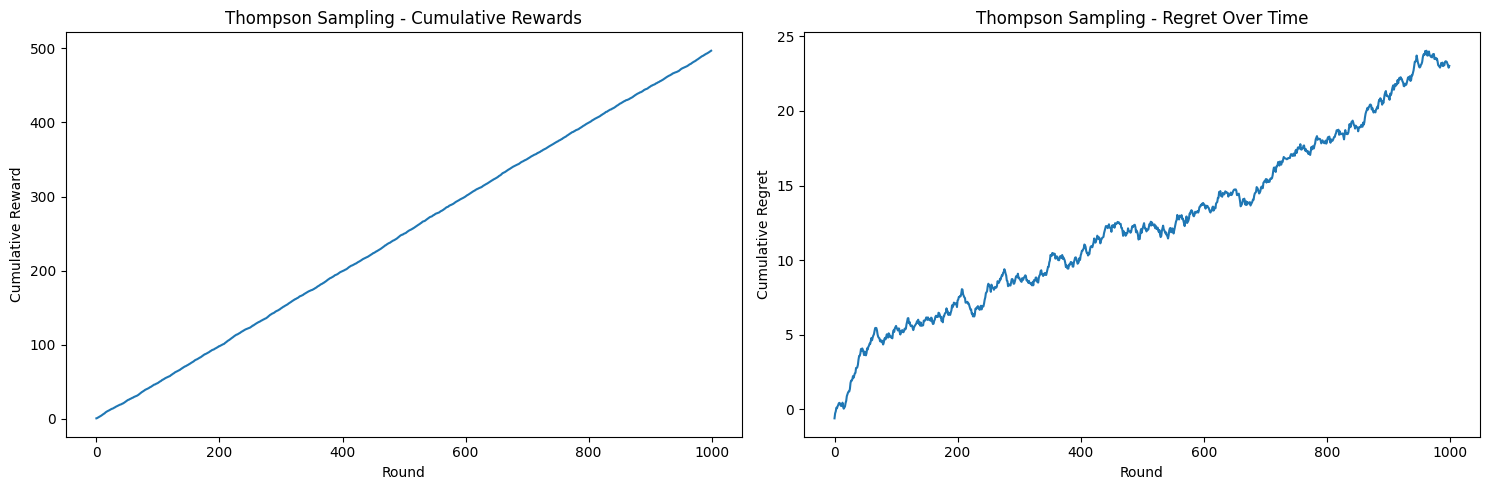

Final Regret: 23.020477253433437
Regret Bound: 164.31676725154983


In [12]:
def run_thompson_sampling_experiment(iterations=1000, arms=4, dimension=3):
    """Modified version that returns data for plotting"""
    from rl.bandits.ThompsonSampling import ThompsonSampling

    thompson = ThompsonSampling(n_arms=arms, n_features=dimension, epsilon=0.01, delta=0.01, R=1)

    cumulative_rewards = []
    regret_history = []

    for t in range(iterations):
        # Generate random context
        context = np.random.rand(arms, dimension)
        option = thompson.run(context=context)

        # Generate rewards
        r = [sum(context[i]) / dimension for i in range(context.shape[0])]

        # Update bandit
        thompson.update(r[option])

        # Track metrics
        cum_reward = sum([item for row in thompson.rewardHistory for item in row])
        cumulative_rewards.append(cum_reward)
        regret_history.append(sum(thompson.regretHistory))

    return {
        'cumulative_rewards': cumulative_rewards,
        'regret_history': regret_history,
        'regret_bound': thompson.regretBound(iterations),
        'final_regret': sum(thompson.regretHistory)
    }


# Run the experiment
results = run_thompson_sampling_experiment(iterations=1000)

# Plot the results however you want
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot cumulative rewards
ax1.plot(results['cumulative_rewards'])
ax1.set_title('Thompson Sampling - Cumulative Rewards')
ax1.set_xlabel('Round')
ax1.set_ylabel('Cumulative Reward')

# Plot regret over time
ax2.plot(results['regret_history'])
ax2.set_title('Thompson Sampling - Regret Over Time')
ax2.set_xlabel('Round')
ax2.set_ylabel('Cumulative Regret')

plt.tight_layout()
plt.show()

print(f"Final Regret: {results['final_regret']}")
print(f"Regret Bound: {results['regret_bound']}")

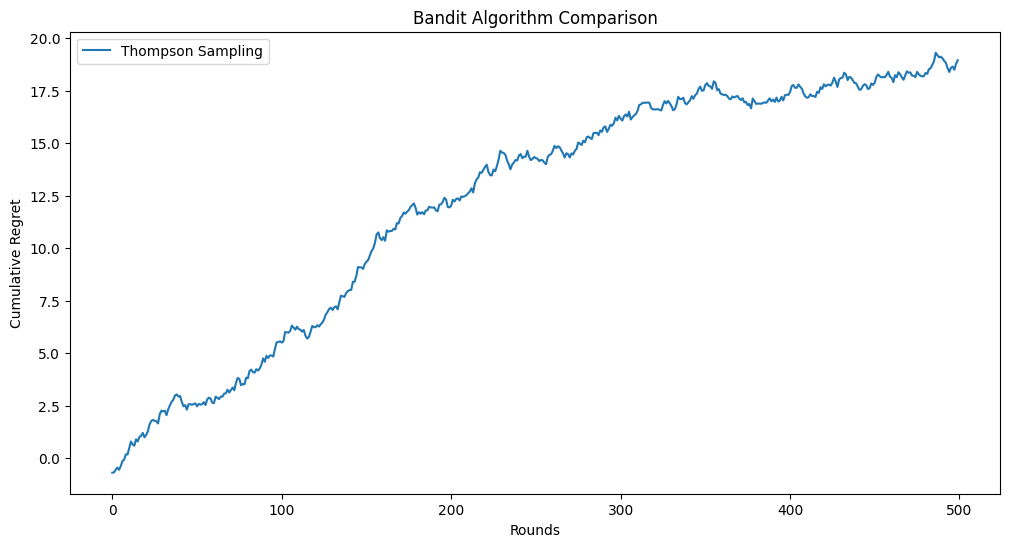

In [13]:
# Compare multiple bandits
def compare_bandits():
    ts_results = run_thompson_sampling_experiment(iterations=500)
    # Add similar functions for other bandits...

    plt.figure(figsize=(12, 6))
    plt.plot(ts_results['regret_history'], label='Thompson Sampling')
    # Add other algorithms...

    plt.xlabel('Rounds')
    plt.ylabel('Cumulative Regret')
    plt.title('Bandit Algorithm Comparison')
    plt.legend()
    plt.show()

compare_bandits()